In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.chart import BarChart, Reference, PieChart
import os
from textblob import TextBlob
from transformers import pipeline

# ─────────────────────────────────────────────
# CONFIGURATION — Edit these to match your file
# ─────────────────────────────────────────────
INPUT_FILE   = "/content/Delhi_Captions_Comments.xlsx"   # Your Excel file name
COMMENT_COL  = "Unnamed: 1"                  # Column name that holds the comment text
OUTPUT_FILE  = "sentiment_results.xlsx"  # Output file name
# ─────────────────────────────────────────────


def load_comments(filepath: str, comment_col: str) -> pd.DataFrame:
    """Load the Excel file and validate the comment column."""
    df = pd.read_excel(filepath)
    print(f"✅ Loaded {len(df):,} rows from '{filepath}'")
    print(f"   Columns found: {list(df.columns)}\n")

    if comment_col not in df.columns:
        # Try to auto-detect a comment-like column
        candidates = [c for c in df.columns if "comment" in c.lower() or "text" in c.lower()]
        if candidates:
            comment_col = candidates[0]
            print(f"⚠️  Column '{comment_col}' not found — using '{comment_col}' instead.")
        else:
            raise ValueError(
                f"Column '{comment_col}' not found. "
                f"Available columns: {list(df.columns)}"
            )

    df = df.dropna(subset=[comment_col]).copy()
    df[comment_col] = df[comment_col].astype(str).str.strip()
    df = df[df[comment_col] != ""]
    return df, comment_col


def analyze_sentiment(df: pd.DataFrame, comment_col: str) -> pd.DataFrame:
    """Run VADER sentiment on every comment and add result columns."""
    analyzer = SentimentIntensityAnalyzer()

    scores = df[comment_col].apply(lambda text: analyzer.polarity_scores(text))
    scores_df = pd.DataFrame(scores.tolist())

    df["Positive Score"]  = scores_df["pos"].round(4)
    df["Negative Score"]  = scores_df["neg"].round(4)
    df["Neutral Score"]   = scores_df["neu"].round(4)
    df["Compound Score"]  = scores_df["compound"].round(4)

    def label(compound):
        if compound >= 0.05:
            return "Positive"
        elif compound <= -0.05:
            return "Negative"
        else:
            return "Neutral"

    df["Sentiment"] = df["Compound Score"].apply(label)
    return df

def analyze_textblob_sentiment(df: pd.DataFrame, comment_col: str) -> pd.DataFrame:
    """Run TextBlob sentiment on every comment and add result columns."""
    def get_textblob_sentiment(text):
        analysis = TextBlob(text)
        polarity = analysis.sentiment.polarity
        if polarity > 0:
            return "Positive"
        elif polarity < 0:
            return "Negative"
        else:
            return "Neutral", polarity

    # Apply TextBlob sentiment analysis
    df["TextBlob Polarity"] = df[comment_col].apply(lambda text: TextBlob(text).sentiment.polarity).round(4)
    df["TextBlob Sentiment"] = df["TextBlob Polarity"].apply(lambda polarity:
        "Positive" if polarity > 0 else ("Negative" if polarity < 0 else "Neutral")
    )
    return df

def analyze_transformers_sentiment(df: pd.DataFrame, comment_col: str, model_name: str, prefix: str) -> pd.DataFrame:
    """Run sentiment analysis using Hugging Face Transformers and add result columns."""
    # Load sentiment analysis pipeline
    sentiment_pipeline = pipeline("sentiment-analysis", model=model_name, tokenizer=model_name)

    # Batch processing for efficiency
    results = sentiment_pipeline(df[comment_col].tolist(), truncation=True)

    # Store raw labels first, then apply mapping
    df[f"{prefix} Sentiment"] = [res['label'] for res in results]
    df[f"{prefix} Confidence"] = [round(res['score'], 4) for res in results]

    # Map 'LABEL_0', 'LABEL_1', etc. to 'Negative', 'Positive', 'Neutral' if needed
    # For models like distilbert-base-uncased-finetuned-sst-2-english, labels are usually 'POSITIVE', 'NEGATIVE'
    # For models like cardiffnlp/twitter-xlm-roberta-base-sentiment, labels are 'LABEL_0' (negative), 'LABEL_1' (neutral), 'LABEL_2' (positive)
    if model_name == "cardiffnlp/twitter-xlm-roberta-base-sentiment":
        print(f"DEBUG: {prefix} Raw Sentiment value counts before mapping: \n{pd.Series([res['label'] for res in results]).value_counts()}") # Debug print
        # The model actually outputs 'positive', 'neutral', 'negative' (lowercase)
        label_map = {"negative": "Negative", "neutral": "Neutral", "positive": "Positive"}
        df[f"{prefix} Sentiment"] = df[f"{prefix} Sentiment"].map(label_map)
        print(f"DEBUG: {prefix} Sentiment value counts after mapping: \n{df[f'{prefix} Sentiment'].value_counts(dropna=False)}") # Debug print
    elif model_name == "distilbert-base-uncased-finetuned-sst-2-english":
        print(f"DEBUG: {prefix} Raw Sentiment value counts before mapping: \n{pd.Series([res['label'] for res in results]).value_counts()}") # Debug print
        label_map = {"POSITIVE": "Positive", "NEGATIVE": "Negative"}
        df[f"{prefix} Sentiment"] = df[f"{prefix} Sentiment"].map(label_map)
        print(f"DEBUG: {prefix} Sentiment value counts after mapping: \n{df[f'{prefix} Sentiment'].value_counts()}") # Debug print
    # For roberta model, typically the labels are 'LABEL_0', 'LABEL_1'
    elif model_name == "siebert/sentiment-roberta-large-english-5gb":
        print(f"DEBUG: {prefix} Raw Sentiment value counts before mapping: \n{pd.Series([res['label'] for res in results]).value_counts()}") # Debug print
        label_map = {"NEGATIVE": "Negative", "POSITIVE": "Positive"}
        df[f"{prefix} Sentiment"] = df[f"{prefix} Sentiment"].map(label_map)
        print(f"DEBUG: {prefix} Sentiment value counts after mapping: \n{df[f'{prefix} Sentiment'].value_counts(dropna=False)}") # Debug print

    return df

def print_sentiment_summary(df: pd.DataFrame, sentiment_column: str, compound_score_column: str = None) -> dict:
    """Print a text summary and return counts for a given sentiment column."""
    counts = df[sentiment_column].value_counts()
    total  = len(df)

    print(f"\n{'=' * 45}")
    print(f"  {sentiment_column.upper()} ANALYSIS SUMMARY")
    print(f"{'=' * 45}")
    for label in ["Positive", "Neutral", "Negative"]:
        n   = counts.get(label, 0)
        pct = n / total * 100
        bar = "█" * int(pct / 2)
        print(f"  {label:<10} {n:>5} ({pct:5.1f}%)  {bar}")
    print(f"  {'Total':<10} {total:>5}")
    print(f"{'=' * 45}")

    if compound_score_column and compound_score_column in df.columns:
        avg = df[compound_score_column].mean()
        overall = "Positive 😊" if avg >= 0.05 else "Negative 😞" if avg <= -0.05 else "Neutral 😐"
        print(f"\n  Avg Score ({compound_score_column}) : {avg:.4f}")
        print(f"  Overall Sentiment ({sentiment_column})  : {overall}\n")
    else:
        print(f"\n  No direct compound/overall score for {sentiment_column}\n")

    return counts.to_dict()


def plot_sentiment_distribution(sentiment_series: pd.Series, title: str, filename: str):
    """Save a bar chart and pie chart of sentiment distribution."""
    counts = sentiment_series.value_counts().to_dict()
    labels  = list(counts.keys())
    values  = list(counts.values())
    colors  = {"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#CCCCCC"} # Updated colors: Green, Red, Gray
    clrs    = [colors.get(l, "grey") for l in labels]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Bar chart
    axes[0].bar(labels, values, color=clrs, edgecolor="white", linewidth=1.2)
    axes[0].set_title("Comment Count by Sentiment")
    axes[0].set_ylabel("Number of Comments")
    for i, v in enumerate(values):
        axes[0].text(i, v + max(values)*0.01, str(v), ha="center", fontweight="bold")

    # Pie chart
    axes[1].pie(values, labels=labels, colors=clrs, autopct="%1.1f%%",
                startangle=140, wedgeprops=dict(edgecolor="white"))
    axes[1].set_title("Sentiment Distribution")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"📊 Charts saved → {filename}")


def save_detailed_results(df: pd.DataFrame, sentiment_col: str, compound_score_col: str, output_file: str, comment_col: str):
    """Write results sheet + summary sheet to Excel with basic formatting."""
    counts = df[sentiment_col].value_counts().to_dict()
    total = len(df)

    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        # Sheet 1 — all comments with scores
        df.to_excel(writer, sheet_name="Sentiment Results", index=False)

        # Sheet 2 — summary table
        summary = pd.DataFrame([
            {"Sentiment": lbl,
             "Count": counts.get(lbl, 0),
             "Percentage": f"{counts.get(lbl, 0)/total*100:.1f}%"}
            for lbl in ["Positive", "Neutral", "Negative"]
        ])
        summary.to_excel(writer, sheet_name="Summary", index=False)

        # Sheet 3 — top 10 most positive & most negative (if compound score exists)
        if compound_score_col and compound_score_col in df.columns:
            # Ensure the columns exist before attempting to select them
            cols_to_select = [comment_col, compound_score_col, sentiment_col]
            available_cols = [col for col in cols_to_select if col in df.columns]

            if len(available_cols) == len(cols_to_select):
                top_pos = df.nlargest(10, compound_score_col)[available_cols]
                top_neg = df.nsmallest(10, compound_score_col)[available_cols]
                top_pos.to_excel(writer, sheet_name="Top Positive", index=False)
                top_neg.to_excel(writer, sheet_name="Top Negative", index=False)
            else:
                print(f"⚠️ Missing one or more key columns for top/bottom comments (expected: {cols_to_select}, found: {available_cols}). Skipping Top Positive/Negative sheet.")
        else:
            print(f"⚠️ No '{compound_score_col}' for {sentiment_col} to determine top/bottom comments. Skipping Top Positive/Negative sheet.")

    # Apply color coding to the Sentiment column
    wb = load_workbook(output_file)
    ws = wb["Sentiment Results"]

    fill_map = {
        "Positive": PatternFill("solid", fgColor="C8E6C9"),
        "Negative": PatternFill("solid", fgColor="FFCDD2"),
        "Neutral":  PatternFill("solid", fgColor="BBDEFB"),
    }

    # Find sentiment_col index
    headers = [cell.value for cell in ws[1]]
    try:
        sent_col_idx = headers.index(sentiment_col) + 1
    except ValueError:
        print(f"Warning: Sentiment column '{sentiment_col}' not found in Excel sheet for formatting.")
        sent_col_idx = None

    if sent_col_idx:
        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            sentiment_cell = row[sent_col_idx - 1]
            fill = fill_map.get(sentiment_cell.value)
            if fill:
                for cell in row:
                    cell.fill = fill

    # Bold headers
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Auto-width for key columns
    for col in ws.columns:
        max_len = max((len(str(c.value or "")) for c in col), default=10)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

    wb.save(output_file)
    print(f"✅ Results saved → {output_file}")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
# Load comments globally so df and COMMENT_COL are available for all analysis steps
if not os.path.exists(INPUT_FILE):
    print(f"❌ File not found: '{INPUT_FILE}'")
    print("   Please set INPUT_FILE at the top of the script to your Excel file path.")
else:
    df, COMMENT_COL  = load_comments(INPUT_FILE, COMMENT_COL)

✅ Loaded 877 rows from '/content/Delhi_Captions_Comments.xlsx'
   Columns found: ['Unnamed: 0', 'Unnamed: 1']



In [8]:
# Load comments globally so df and COMMENT_COL are available for all analysis steps
if not os.path.exists(INPUT_FILE):
    print(f"❌ File not found: '{INPUT_FILE}'")
    print("   Please set INPUT_FILE at the top of the script to your Excel file path.")
else:
    df, COMMENT_COL  = load_comments(INPUT_FILE, COMMENT_COL)


# --- VADER Sentiment Analysis --- # The actual analysis will be in separate cells


✅ Loaded 877 rows from '/content/Delhi_Captions_Comments.xlsx'
   Columns found: ['Unnamed: 0', 'Unnamed: 1']



In [9]:
# --- VADER Sentiment Analysis ---
print("\n" + "=" * 45)
print("         VADER SENTIMENT ANALYSIS")
print("=" * 45)
df = analyze_sentiment(df, COMMENT_COL)
vader_counts = print_sentiment_summary(df, "Sentiment", "Compound Score")
plot_sentiment_distribution(df["Sentiment"], "VADER Sentiment Distribution", "vader_sentiment_charts.png")
save_detailed_results(df, "Sentiment", "Compound Score", "vader_sentiment_results.xlsx", COMMENT_COL)
print("\n🎉 VADER analysis complete.")


         VADER SENTIMENT ANALYSIS

  SENTIMENT ANALYSIS SUMMARY
  Positive     470 ( 55.4%)  ███████████████████████████
  Neutral      302 ( 35.6%)  █████████████████
  Negative      77 (  9.1%)  ████
  Total        849

  Avg Score (Compound Score) : 0.3326
  Overall Sentiment (Sentiment)  : Positive 😊

📊 Charts saved → vader_sentiment_charts.png
✅ Results saved  → vader_sentiment_results.xlsx

🎉 VADER analysis complete.


In [ ]:
%pip install vaderSentiment textblob transformers openpyxl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.1 MB/s eta 0:00:00


In [ ]:
# --- TextBlob Sentiment Analysis ---
print("\n" + "=" * 45)
print("         TEXTBLOB SENTIMENT ANALYSIS")
print("=" * 45)
df = analyze_textblob_sentiment(df, COMMENT_COL)
textblob_counts = print_sentiment_summary(df, "TextBlob Sentiment", "TextBlob Polarity")
plot_sentiment_distribution(df["TextBlob Sentiment"], "TextBlob Sentiment Distribution", "textblob_sentiment_charts.png")
save_detailed_results(df, "TextBlob Sentiment", "TextBlob Polarity", "textblob_sentiment_results.xlsx", COMMENT_COL)
print("\n🎉 TextBlob analysis complete.")


         TEXTBLOB SENTIMENT ANALYSIS

  TEXTBLOB SENTIMENT ANALYSIS SUMMARY
  Positive     222 ( 26.1%)  █████████████
  Neutral      582 ( 68.6%)  ██████████████████████████████████
  Negative      45 (  5.3%)  ██
  Total        849

  Avg Score (TextBlob Polarity) : 0.1050
  Overall Sentiment (TextBlob Sentiment)  : Positive 😊

📊 Charts saved → textblob_sentiment_charts.png
✅ Results saved  → textblob_sentiment_results.xlsx

🎉 TextBlob analysis complete.


In [ ]:
# --- Hugging Face Transformers Sentiment Analysis (distilbert) ---
print("\n" + "=" * 45)
print("         TRANSFORMERS (DISTILBERT) SENTIMENT ANALYSIS")
print("=" * 45)
df = analyze_transformers_sentiment(df, COMMENT_COL, "distilbert-base-uncased-finetuned-sst-2-english", "DistilBERT")
distilbert_counts = print_sentiment_summary(df, "DistilBERT Sentiment", "DistilBERT Confidence")
plot_sentiment_distribution(df["DistilBERT Sentiment"], "DistilBERT Sentiment Distribution", "distilbert_sentiment_charts.png")
save_detailed_results(df, "DistilBERT Sentiment", "DistilBERT Confidence", "distilbert_sentiment_results.xlsx", COMMENT_COL)
print("\n🎉 DistilBERT analysis complete.")


         TRANSFORMERS (DISTILBERT) SENTIMENT ANALYSIS


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DEBUG: DistilBERT Raw Sentiment value counts before mapping: 
POSITIVE    439
NEGATIVE    410
Name: count, dtype: int64
DEBUG: DistilBERT Sentiment value counts after mapping: 
DistilBERT Sentiment
Positive    439
Negative    410
Name: count, dtype: int64

  DISTILBERT SENTIMENT ANALYSIS SUMMARY
  Positive     439 ( 51.7%)  █████████████████████████
  Neutral        0 (  0.0%)  
  Negative     410 ( 48.3%)  ████████████████████████
  Total        849

  Avg Score (DistilBERT Confidence) : 0.9128
  Overall Sentiment (DistilBERT Sentiment)  : Positive 😊

📊 Charts saved → distilbert_sentiment_charts.png
✅ Results saved  → distilbert_sentiment_results.xlsx

🎉 DistilBERT analysis complete.


In [ ]:
# --- Hugging Face Transformers Sentiment Analysis (XLM-RoBERTa) ---
print("\n" + "=" * 45)
print("         TRANSFORMERS (XLM-ROBERTA) SENTIMENT ANALYSIS")
print("=" * 45)
df = analyze_transformers_sentiment(df, COMMENT_COL, "cardiffnlp/twitter-xlm-roberta-base-sentiment", "XLMRoberta")
xlmroberta_counts = print_sentiment_summary(df, "XLMRoberta Sentiment", "XLMRoberta Confidence")
plot_sentiment_distribution(df["XLMRoberta Sentiment"], "XLM-RoBERTa Sentiment Distribution", "xlmroberta_sentiment_charts.png")
save_detailed_results(df, "XLMRoberta Sentiment", "XLMRoberta Confidence", "xlmroberta_sentiment_results.xlsx", COMMENT_COL)
print("\n🎉 XLM-RoBERTa analysis complete.")


         TRANSFORMERS (XLM-ROBERTA) SENTIMENT ANALYSIS


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DEBUG: XLMRoberta Raw Sentiment value counts before mapping: 
positive    387
neutral     295
negative    167
Name: count, dtype: int64
DEBUG: XLMRoberta Sentiment value counts after mapping: 
XLMRoberta Sentiment
Positive    387
Neutral     295
Negative    167
Name: count, dtype: int64

  XLMROBERTA SENTIMENT ANALYSIS SUMMARY
  Positive     387 ( 45.6%)  ██████████████████████
  Neutral      295 ( 34.7%)  █████████████████
  Negative     167 ( 19.7%)  █████████
  Total        849

  Avg Score (XLMRoberta Confidence) : 0.6257
  Overall Sentiment (XLMRoberta Sentiment)  : Positive 😊

📊 Charts saved → xlmroberta_sentiment_charts.png
✅ Results saved  → xlmroberta_sentiment_results.xlsx

🎉 XLM-RoBERTa analysis complete.


In [ ]:
# --- Hugging Face Transformers Sentiment Analysis (XLM-RoBERTa) ---
print("\n" + "=" * 45)
print("         TRANSFORMERS (XLM-ROBERTA) SENTIMENT ANALYSIS")
print("=" * 45)
df = analyze_transformers_sentiment(df, COMMENT_COL, "cardiffnlp/twitter-xlm-roberta-base-sentiment", "XLMRoberta")
xlmroberta_counts = print_sentiment_summary(df, "XLMRoberta Sentiment", "XLMRoberta Confidence")
plot_sentiment_distribution(df["XLMRoberta Sentiment"], "XLM-RoBERTa Sentiment Distribution", "xlmroberta_sentiment_charts.png")
save_detailed_results(df, "XLMRoberta Sentiment", "XLMRoberta Confidence", "xlmroberta_sentiment_results.xlsx", COMMENT_COL)
print("\n🎉 XLM-RoBERTa analysis complete.")


         TRANSFORMERS (XLM-ROBERTA) SENTIMENT ANALYSIS


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DEBUG: XLMRoberta Raw Sentiment value counts before mapping: 
positive    387
neutral     295
negative    167
Name: count, dtype: int64
DEBUG: XLMRoberta Sentiment value counts after mapping: 
XLMRoberta Sentiment
Positive    387
Neutral     295
Negative    167
Name: count, dtype: int64

  XLMROBERTA SENTIMENT ANALYSIS SUMMARY
  Positive     387 ( 45.6%)  ██████████████████████
  Neutral      295 ( 34.7%)  █████████████████
  Negative     167 ( 19.7%)  █████████
  Total        849

  Avg Score (XLMRoberta Confidence) : 0.6257
  Overall Sentiment (XLMRoberta Sentiment)  : Positive 😊

📊 Charts saved → xlmroberta_sentiment_charts.png
✅ Results saved  → xlmroberta_sentiment_results.xlsx

🎉 XLM-RoBERTa analysis complete.


In [ ]:
import pandas as pd

# Calculate sentiment percentages from the 'counts' dictionary
total_comments = sum(xlmroberta_counts.values())
sentiment_percent = pd.Series({
    label: (count / total_comments * 100) for label, count in xlmroberta_counts.items()
})

display(sentiment_percent)

,0


### VADER Sentiment Percentage Bar Chart

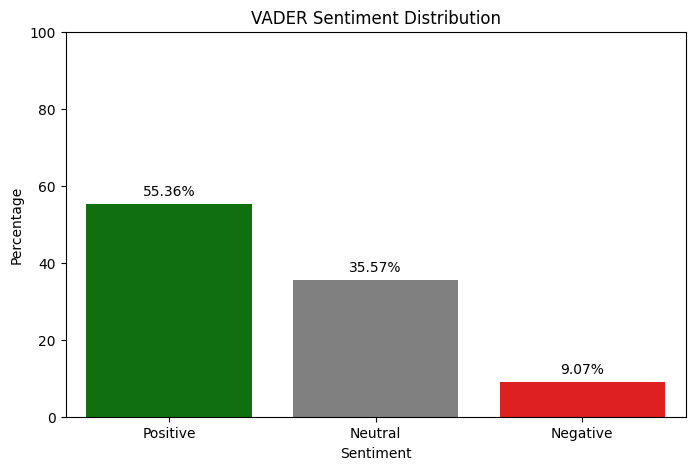

In [ ]:
# Calculate VADER sentiment percentages
total_vader_comments = sum(vader_counts.values())
vader_sentiment_percent = pd.Series({
    label: (count / total_vader_comments * 100) for label, count in vader_counts.items()
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=vader_sentiment_percent.index, y=vader_sentiment_percent.values, palette=['green', 'grey', 'red'], hue=vader_sentiment_percent.index, legend=False)
plt.title('VADER Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Add percentage labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

### TextBlob Sentiment Percentage Bar Chart

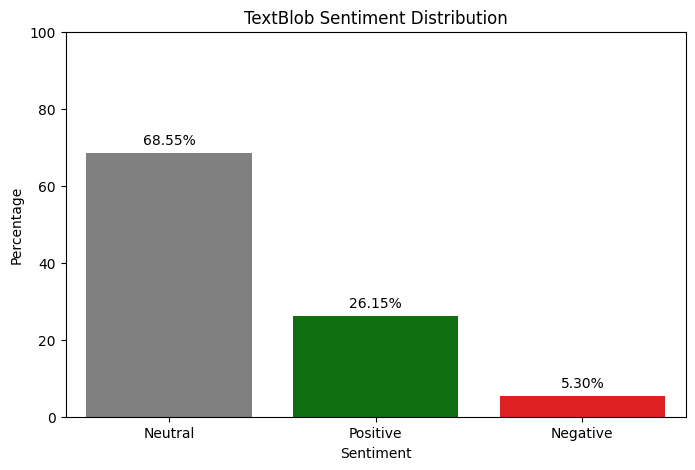

In [ ]:
# Calculate TextBlob sentiment percentages
total_textblob_comments = sum(textblob_counts.values())
textblob_sentiment_percent = pd.Series({
    label: (count / total_textblob_comments * 100) for label, count in textblob_counts.items()
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=textblob_sentiment_percent.index, y=textblob_sentiment_percent.values, palette=['grey', 'green', 'red'], hue=textblob_sentiment_percent.index, legend=False)
plt.title('TextBlob Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Add percentage labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

### DistilBERT Sentiment Percentage Bar Chart

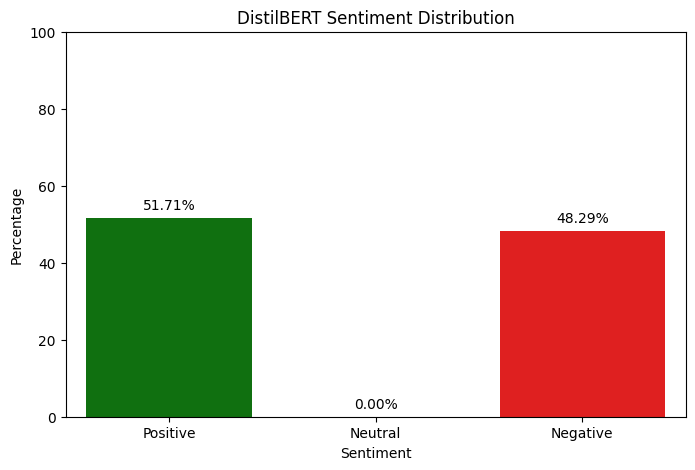

In [ ]:
# Calculate DistilBERT sentiment percentages
total_distilbert_comments = sum(distilbert_counts.values())
distilbert_sentiment_percent = pd.Series({
    label: (distilbert_counts.get(label, 0) / total_distilbert_comments * 100)
    for label in ['Positive', 'Neutral', 'Negative'] # Ensure Neutral is included
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=distilbert_sentiment_percent.index, y=distilbert_sentiment_percent.values, palette=['green', 'grey', 'red'], hue=distilbert_sentiment_percent.index, legend=False)
plt.title('DistilBERT Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Add percentage labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

In [10]:
import sys

!{sys.executable} -m pip install transformers[torch] accelerate pandas matplotlib seaborn openpyxl

In [ ]:
import pandas as pd

file_path = '/content/Delhi_Captions_Comments.xlsx'
df = pd.read_excel(file_path)

print("DataFrame loaded successfully. Here are the first 5 rows:")
display(df.head())

DataFrame loaded successfully. Here are the first 5 rows:


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,NaN,Comments for video ID: L1UoU1mhKmM
2,NaN,1. Radha ❤❤❤
3,NaN,2. This is the best interview
4,NaN,3. Welcome to RCB


In [ ]:
df = df.dropna(subset=['Unnamed: 1'])
df = df.rename(columns={'Unnamed: 1': 'Comments'})

print("Cleaned DataFrame (first 5 rows):")
display(df.head())

Cleaned DataFrame (first 5 rows):


,Unnamed: 0,Comments
1,NaN,Comments for video ID: L1UoU1mhKmM
2,NaN,1. Radha ❤❤❤
3,NaN,2. This is the best interview
4,NaN,3. Welcome to RCB
5,NaN,4. Very good all rounder player


In [ ]:
from transformers import pipeline

# Initialize the sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment")

# Apply sentiment analysis to the 'Comments' column
df['Sentiment_Result'] = df['Comments'].apply(lambda x: sentiment_pipeline(x)[0])

print("Sentiment analysis complete. Here are the first 5 rows with sentiment results:")
display(df.head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment analysis complete. Here are the first 5 rows with sentiment results:


,Unnamed: 0,Comments,Sentiment_Result
1,NaN,Comments for video ID: L1UoU1mhKmM,"{'label': 'neutral', 'score': 0.836644172668457}"
2,NaN,1. Radha ❤❤❤,"{'label': 'positive', 'score': 0.7925287485122..."
3,NaN,2. This is the best interview,"{'label': 'positive', 'score': 0.9376060962677..."
4,NaN,3. Welcome to RCB,"{'label': 'positive', 'score': 0.710676372051239}"
5,NaN,4. Very good all rounder player,"{'label': 'positive', 'score': 0.8780766725540..."


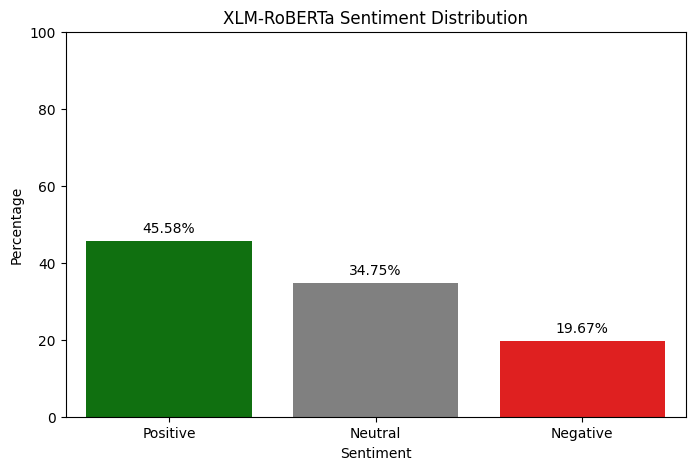

In [ ]:
# Calculate XLM-RoBERTa sentiment percentages
total_xlmroberta_comments = sum(xlmroberta_counts.values())
xlmroberta_sentiment_percent = pd.Series({
    label: (xlmroberta_counts.get(label, 0) / total_xlmroberta_comments * 100)
    for label in ['Positive', 'Neutral', 'Negative'] # Ensure all labels are included
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=xlmroberta_sentiment_percent.index, y=xlmroberta_sentiment_percent.values, palette=['green', 'grey', 'red'], hue=xlmroberta_sentiment_percent.index, legend=False)
plt.title('XLM-RoBERTa Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage')
plt.ylim(0, 100)

# Add percentage labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

In [25]:
pip install afinn pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=046436dba40b31eacc76e4aea6db8229b1308c4e87261a48d98c3b5ea02a409b
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [26]:
import pandas as pd
from afinn import Afinn
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
file_path = '/content/Delhi_Captions_Comments.xlsx'
df = pd.read_excel(file_path)

# The text column identified in previous turns
text_column = 'Unnamed: 1'

# Drop rows where the text column is NaN to avoid errors
df.dropna(subset=[text_column], inplace=True)

# Convert text to string type
df[text_column] = df[text_column].astype(str)

# Initialize AFINN
afinn = Afinn(emoticons=True)

# Apply AFINN sentiment scoring
df['afinn_score'] = df[text_column].apply(lambda text: afinn.score(text))

# Classify sentiment based on AFINN score
def classify_afinn_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['afinn_sentiment'] = df['afinn_score'].apply(classify_afinn_sentiment)

# Display the first few rows with AFINN sentiment results
print("DataFrame with AFINN Sentiment Analysis:")
display(df.head())

DataFrame with AFINN Sentiment Analysis:


,Unnamed: 0,Unnamed: 1,afinn_score,afinn_sentiment
1,NaN,Comments for video ID: L1UoU1mhKmM,0.0,Neutral
2,NaN,1. Radha ❤❤❤,0.0,Neutral
3,NaN,2. This is the best interview,3.0,Positive
4,NaN,3. Welcome to RCB,2.0,Positive
5,NaN,4. Very good all rounder player,3.0,Positive


AFINN Sentiment Counts:
afinn_sentiment
Neutral     502
Positive    294
Negative     53
Name: count, dtype: int64

AFINN Sentiment Percentages:
afinn_sentiment
Neutral     59.13
Positive    34.63
Negative     6.24
Name: count, dtype: float64


/tmp/ipykernel_4775/164076980.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=afinn_sentiment_counts.index, y=afinn_sentiment_counts.values,


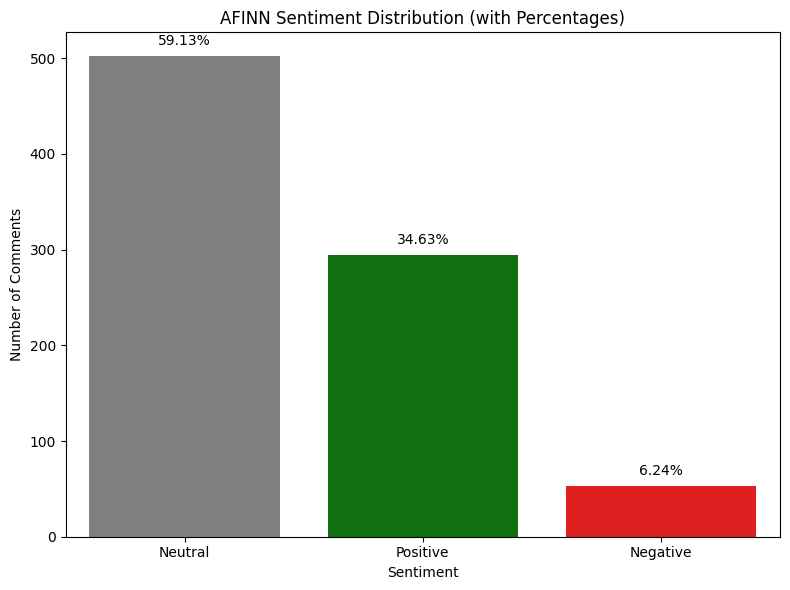

In [28]:
afinn_sentiment_counts = df['afinn_sentiment'].value_counts()
print("AFINN Sentiment Counts:")
print(afinn_sentiment_counts)

total_comments = afinn_sentiment_counts.sum()
afinn_sentiment_percentages = (afinn_sentiment_counts / total_comments * 100).round(2)
print("\nAFINN Sentiment Percentages:")
print(afinn_sentiment_percentages)

plt.figure(figsize=(8, 6))

# Define custom colors
sentiment_colors = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'grey'
}

# Ensure the order of bars matches the sentiment_counts index and map colors
sns.barplot(x=afinn_sentiment_counts.index, y=afinn_sentiment_counts.values,
            palette=[sentiment_colors[s] for s in afinn_sentiment_counts.index])

plt.title('AFINN Sentiment Distribution (with Percentages)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')

# Add percentage labels on top of bars
for index, row in afinn_sentiment_counts.reset_index().iterrows():
    sentiment_label = row['afinn_sentiment']
    count = row['count']
    percentage = afinn_sentiment_percentages[sentiment_label]
    plt.text(index, count + (total_comments * 0.01),
             f'{percentage:.2f}%', color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()